# ML for Social Good — Explainable Screening for Elevated HbA1c

**Mission Health · MCA 521-4 CIA 3**

This notebook documents an end-to-end, leakage-safe ensemble classification system using NHANES August 2021–August 2023. It estimates whether a respondent older than 18 has measured HbA1c of at least 5.7%. The result is a screening-prioritization prototype, not a diagnosis or future-risk forecast.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.config import FEATURE_COLUMNS, TARGET_COLUMN
from src.data_pipeline import build_analytic_dataset
from src.train import make_splits, run_training


## 1. Impact framing

The intended beneficiaries are adults who may need confirmatory testing and under-resourced clinics that cannot test everyone immediately. The measurable prototype impact is reported as referrals, true elevated cases captured, missed elevated cases, and false referrals per 100 screened adults. Human review and laboratory confirmation remain mandatory.

In [2]:
dataset, audit = build_analytic_dataset()
display(pd.Series(audit).to_frame('value'))
display(dataset.head())
print('Shape:', dataset.shape, 'Target rate:', f"{dataset[TARGET_COLUMN].mean():.1%}")

,value
source_rows,"{'demo': 11933, 'bmx': 8860, 'bpxo': 7801, 'pa..."
adult_demo_rows,7969
analytic_rows,5872
positive_target_rows,2300
negative_target_rows,3572
positive_target_rate,0.391689
minimum_age,19
maximum_age_code,80
age_19_rows,105
age_19_missing_education_rows,105


,age,income_ratio,bmi,waist_cm,mean_systolic_bp,mean_diastolic_bp,moderate_activity_min_week,vigorous_activity_min_week,sedentary_min_day,sex,education,smoking_history,current_smoking,elevated_hba1c
0,43.0,5.00,27.0,98.3,132.666667,96.000000,135.0,135.000000,360.0,Male,College graduate or above,Ever,Not current,0
1,66.0,5.00,33.5,114.7,117.000000,78.666667,180.0,135.000000,480.0,Male,College graduate or above,Ever,Not current,0
2,44.0,1.41,29.7,93.5,109.000000,78.333333,20.0,0.000000,240.0,Female,High school/GED,Never,Not current,1
3,34.0,1.33,30.2,106.1,115.000000,73.666667,30.0,6.923077,180.0,Male,Some college/AA,Ever,Not current,0
4,68.0,1.32,42.6,122.0,141.333333,76.000000,0.0,0.000000,1200.0,Female,College graduate or above,Never,Not current,1


Shape: (5872, 14) Target rate: 39.2%


## 2. Wrangling, feature engineering, and leakage prevention

The six XPT files are validated and joined one-to-one by `SEQN`. The filter is strictly `RIDAGEYR > 18`; raw HbA1c is used only to construct the target and both it and `SEQN` are removed before modelling. Refused/don't-know codes become missing. Mean blood pressure, weekly activity, and adult smoking status are derived from the documented source fields.

In [3]:
missing = dataset[FEATURE_COLUMNS].isna().mean().mul(100).sort_values(ascending=False)
display(missing.to_frame('missing_percent'))
splits = make_splits(dataset)
pd.DataFrame({name: {'rows': len(splits[f'y_{name}']), 'positive_rate': splits[f'y_{name}'].mean()} for name in ['train','validation','test']}).T

,missing_percent
income_ratio,12.806540
waist_cm,4.581063
mean_systolic_bp,3.167575
mean_diastolic_bp,3.167575
education,1.822207
bmi,1.430518
moderate_activity_min_week,0.732289
sedentary_min_day,0.715259
vigorous_activity_min_week,0.613079
current_smoking,0.119210


,rows,positive_rate
train,4110.0,0.391727
validation,881.0,0.391600
test,881.0,0.391600


All median imputation, missingness indicators, 1st/99th percentile clipping, scaling, and one-hot encoding are fitted inside each training/CV fold. Model selection and the F2 decision threshold use validation data; the test set is evaluated once after all choices are frozen.

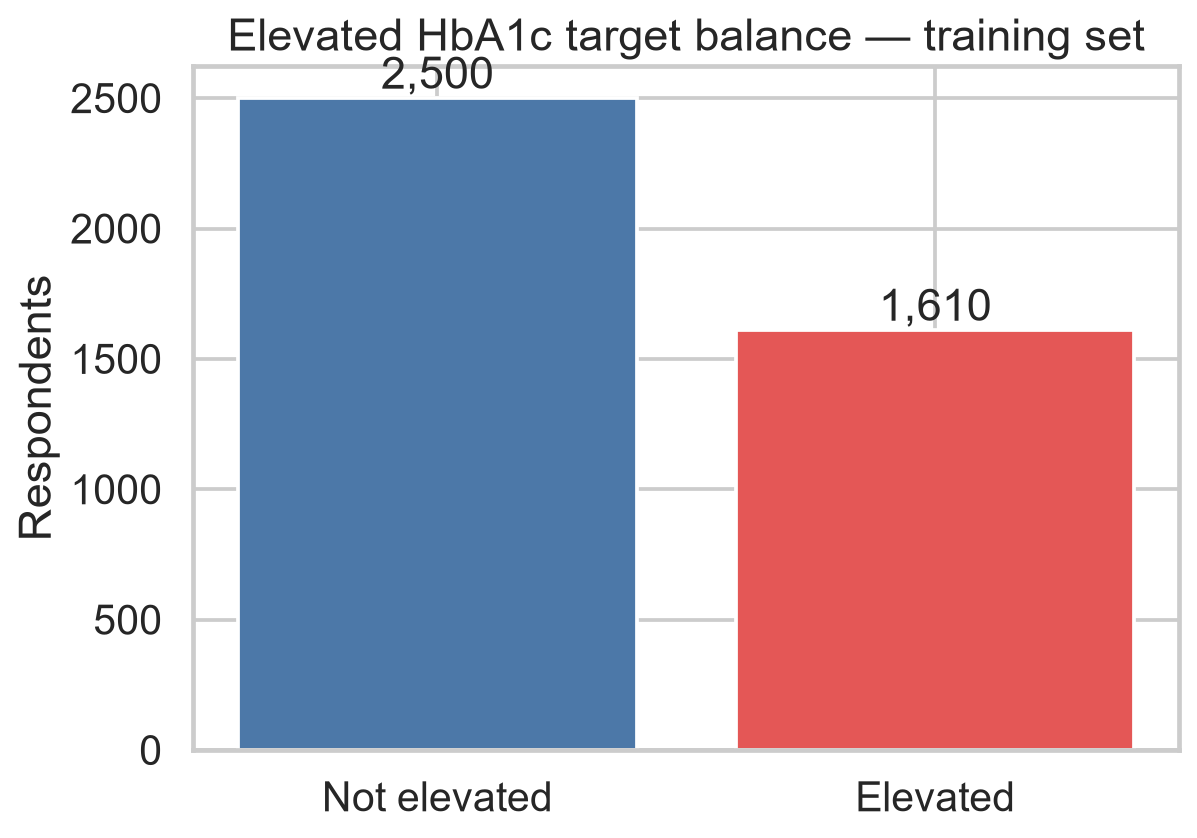

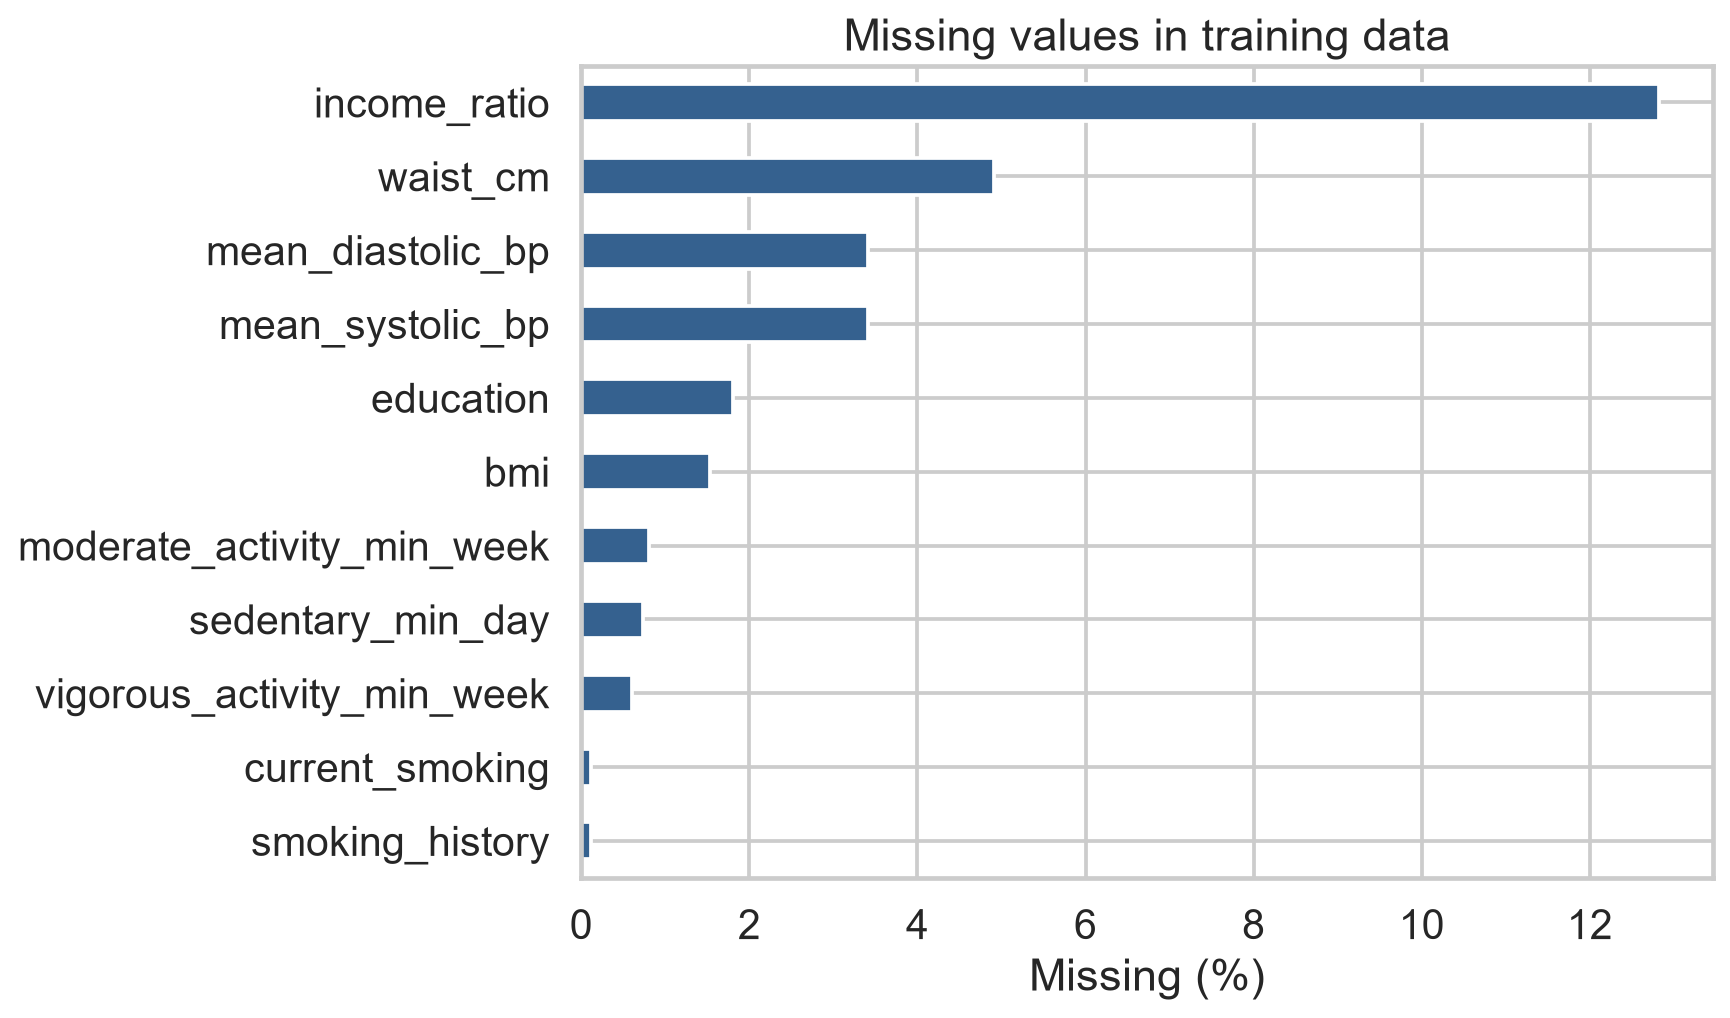

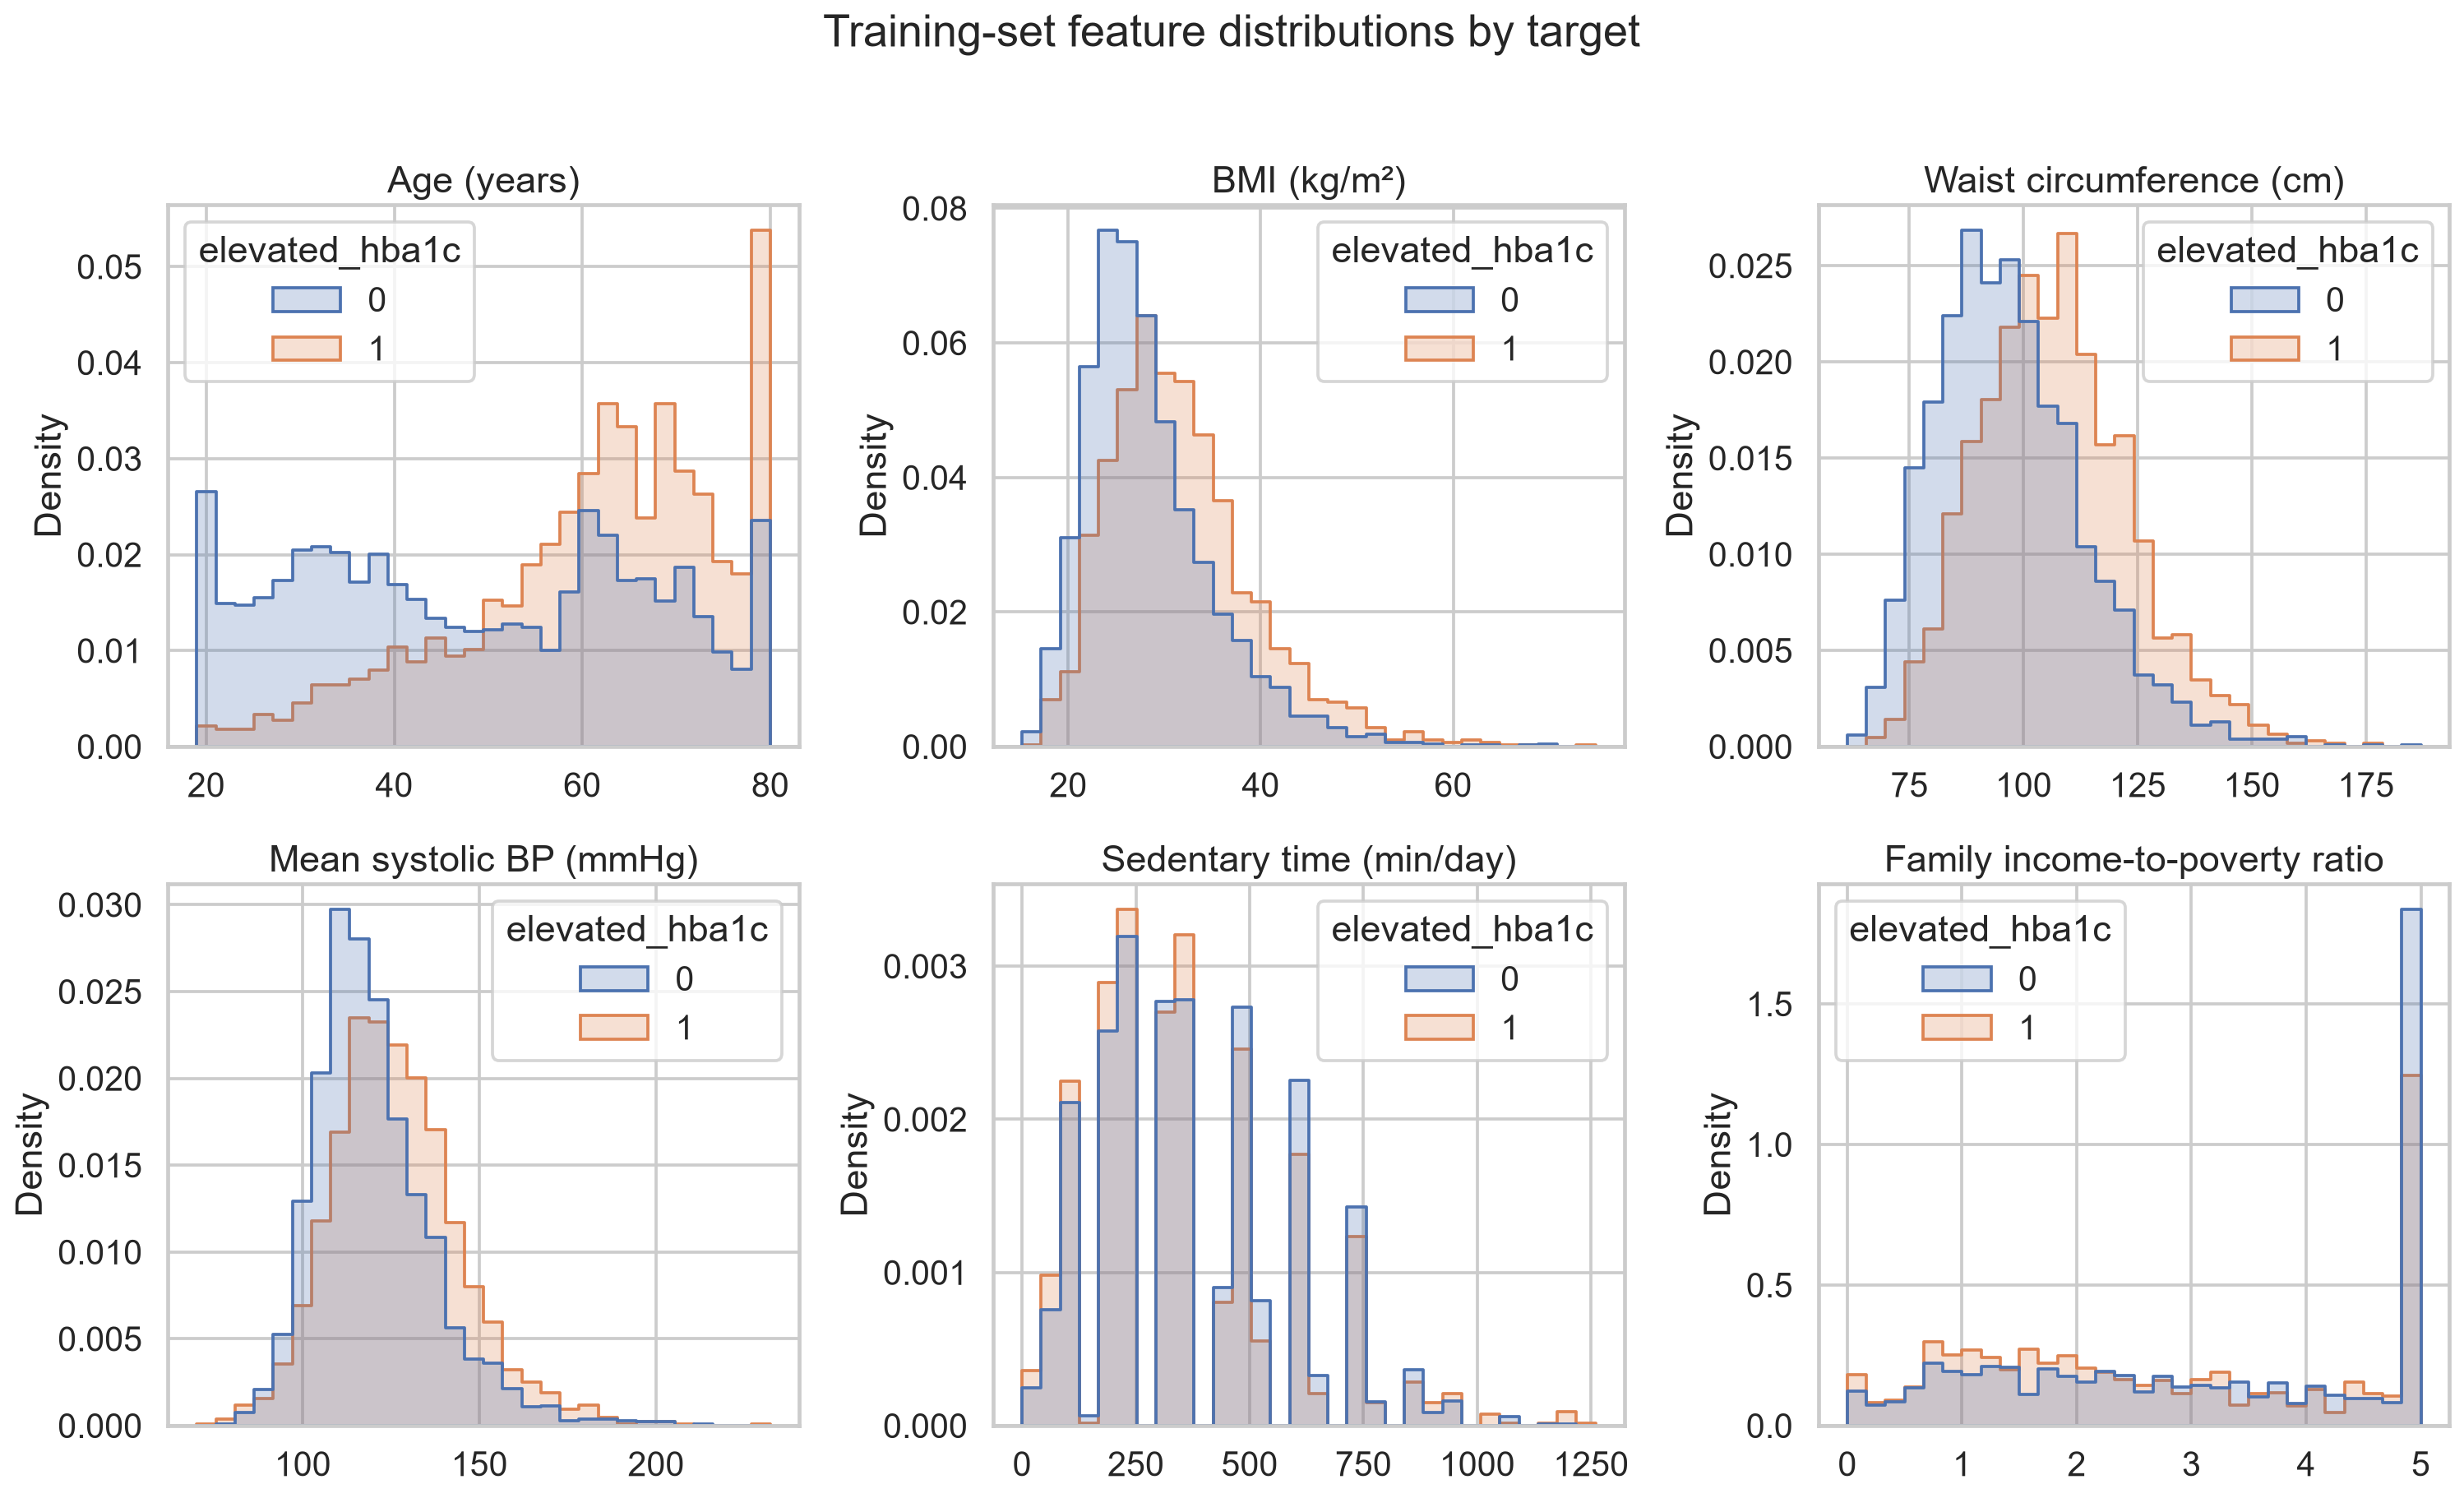

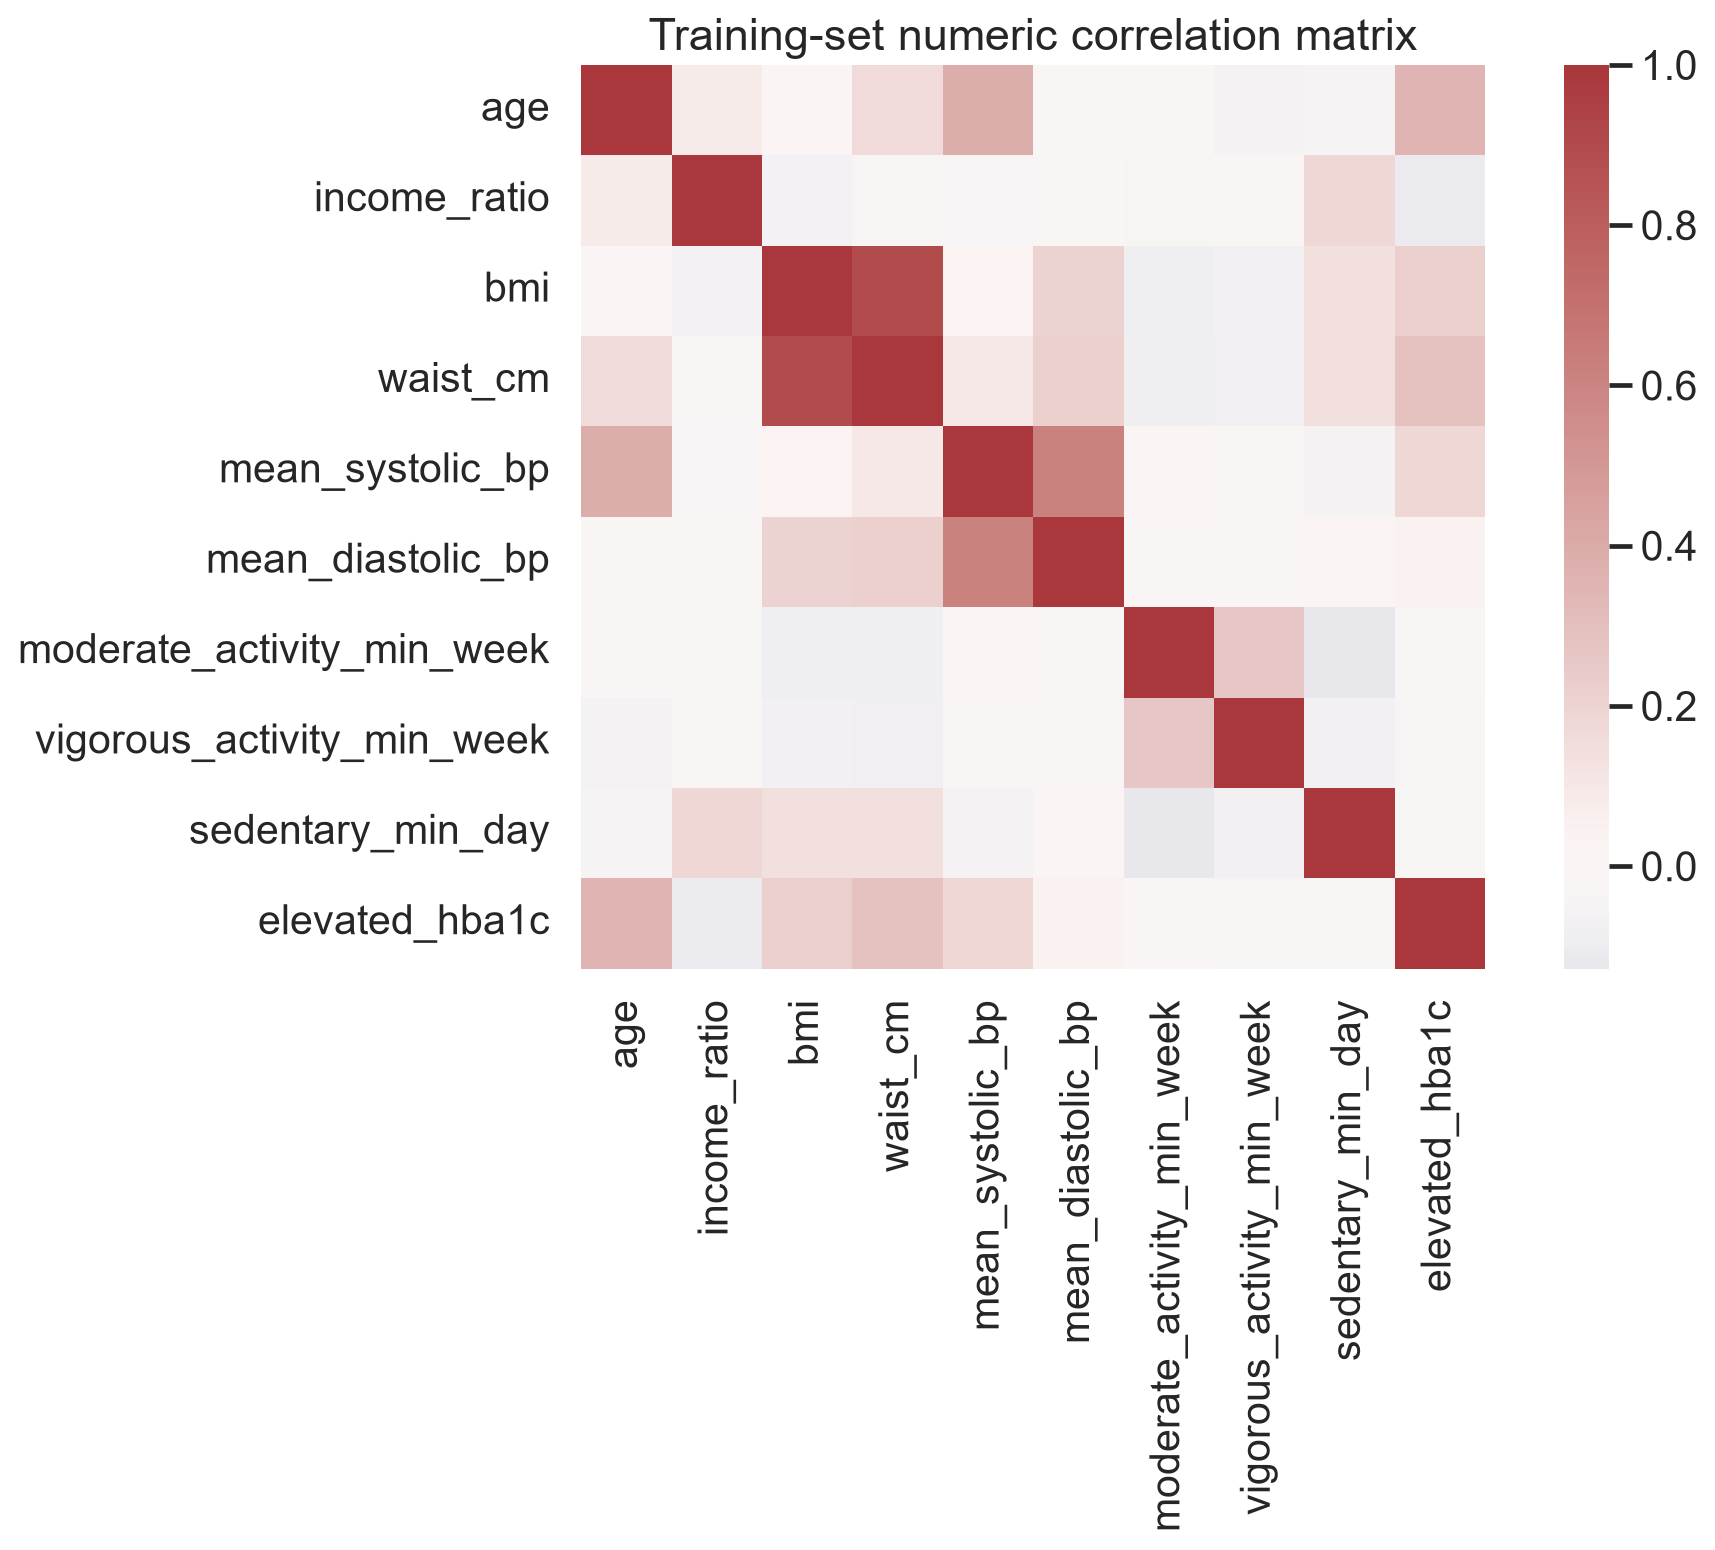

In [4]:
for figure in ['eda_target_balance.png', 'eda_missingness.png', 'eda_numeric_distributions.png', 'eda_correlation.png']:
    path = PROJECT_ROOT / 'reports' / 'figures' / figure
    if path.exists():
        display(Image(filename=str(path), width=850))

## 3. Baseline and ensemble comparison

The required models are Logistic Regression, Random Forest bagging, XGBoost boosting, and a heterogeneous stack. The stack combines all three base learners and trains its Logistic Regression meta-learner only on out-of-fold probabilities. Run `python -m src.train` from the repository root to reproduce the complete search and artifacts.

In [5]:
results_path = PROJECT_ROOT / 'reports' / 'test_model_comparison.csv'
if results_path.exists():
    results = pd.read_csv(results_path)
    display(results[['model_label','roc_auc','average_precision','precision','recall','f1','specificity','threshold']].round(3))
    comparison = json.loads((PROJECT_ROOT / 'reports' / 'ensemble_vs_baseline.json').read_text())
    display(pd.Series(comparison).to_frame('value'))
else:
    print('Final results not generated. Run: python -m src.train')

,model_label,roc_auc,average_precision,precision,recall,f1,specificity,threshold
0,Random Forest,0.782,0.663,0.534,0.899,0.670,0.496,0.365
1,Heterogeneous Stacking,0.781,0.666,0.534,0.899,0.670,0.494,0.245
2,XGBoost,0.779,0.663,0.517,0.904,0.658,0.455,0.245
3,Logistic Regression,0.771,0.651,0.510,0.933,0.660,0.424,0.220


,value
baseline_test_roc_auc,0.770939
stacking_test_roc_auc,0.781251
stacking_minus_baseline_roc_auc,0.010313
stacking_outperformed_baseline_roc_auc,True


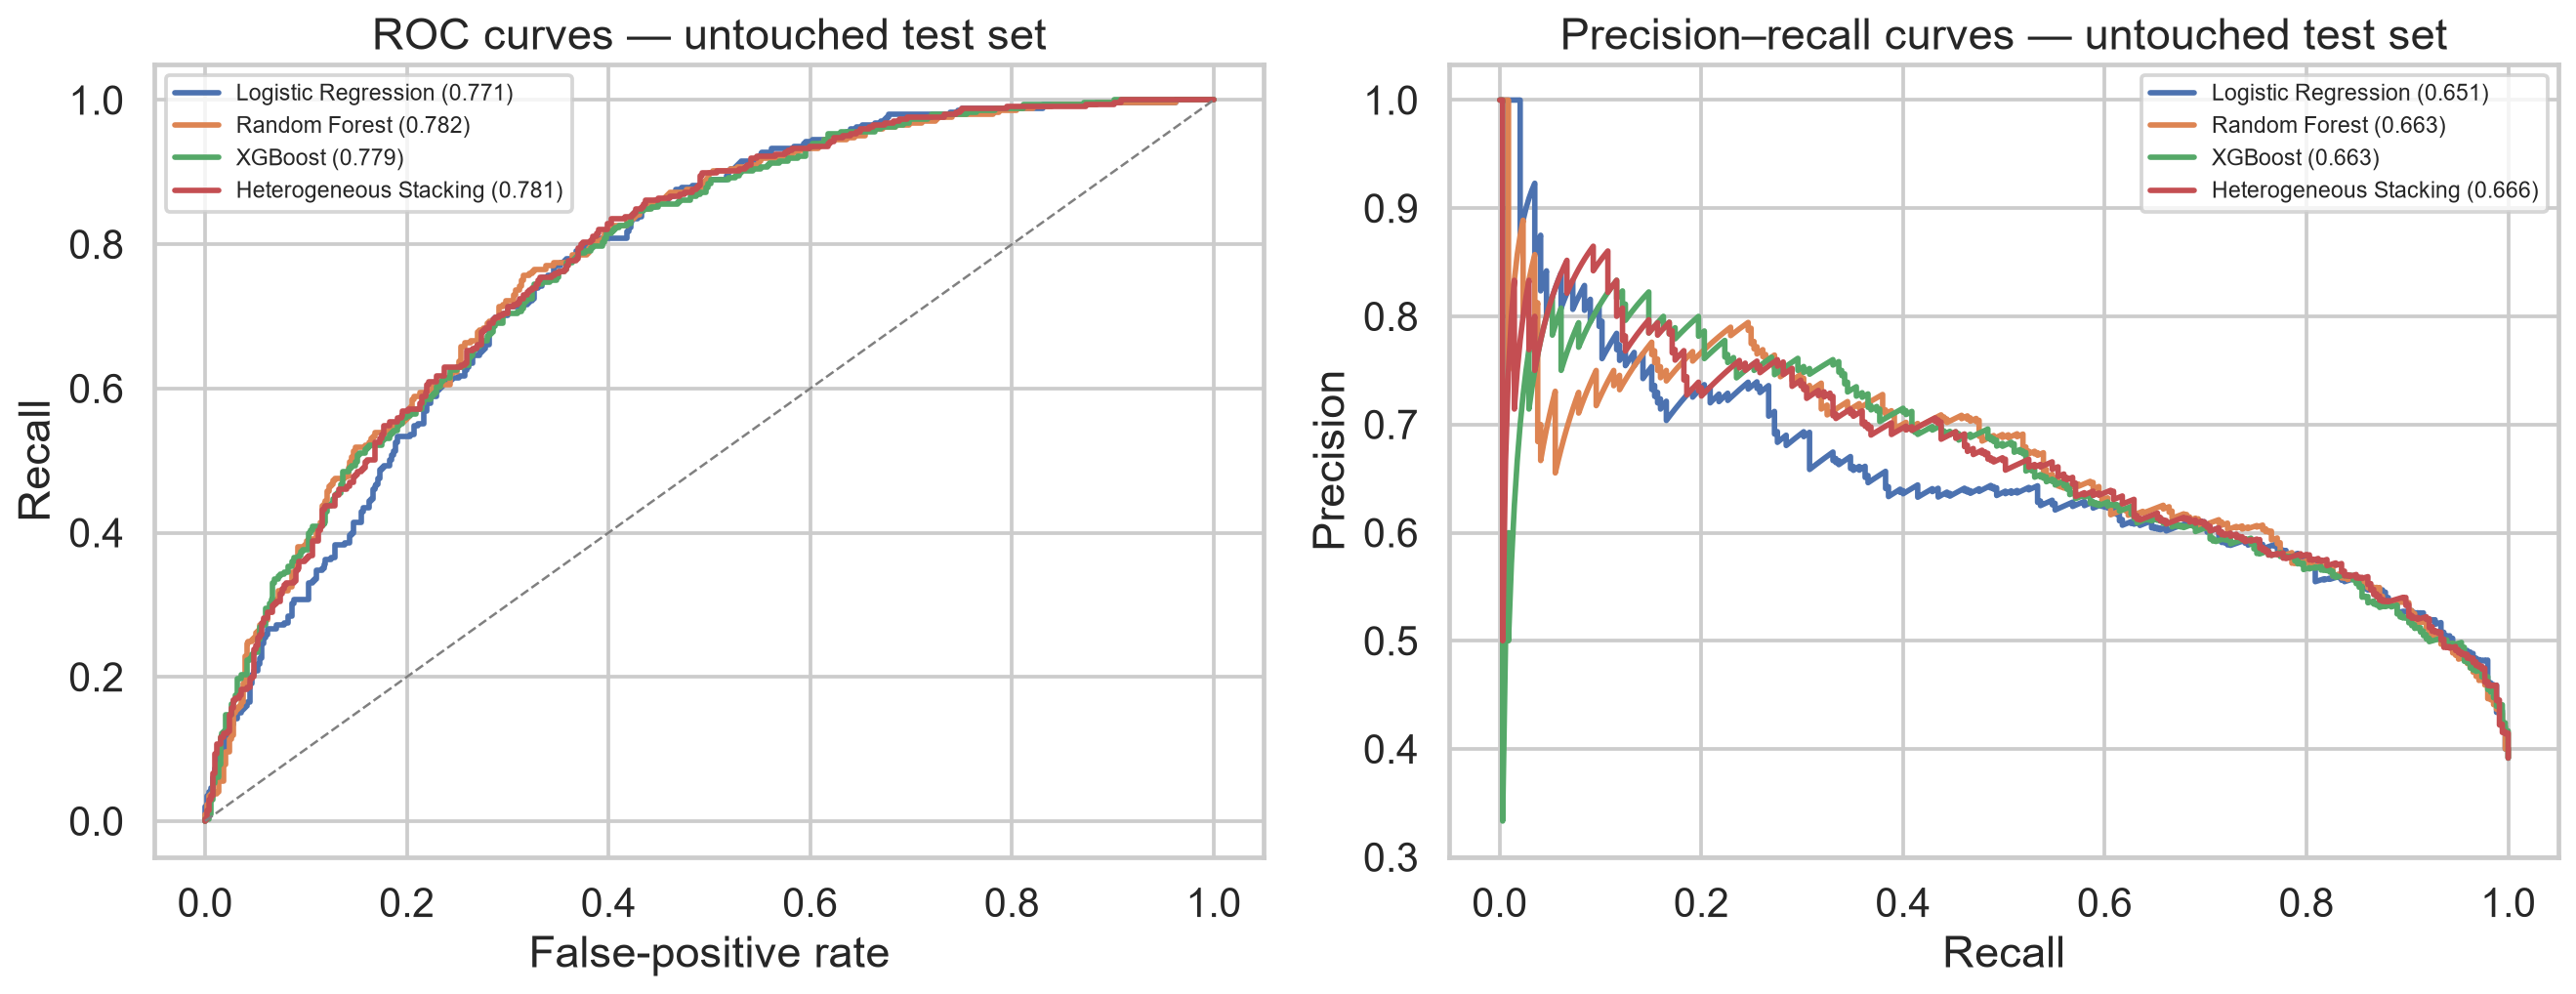

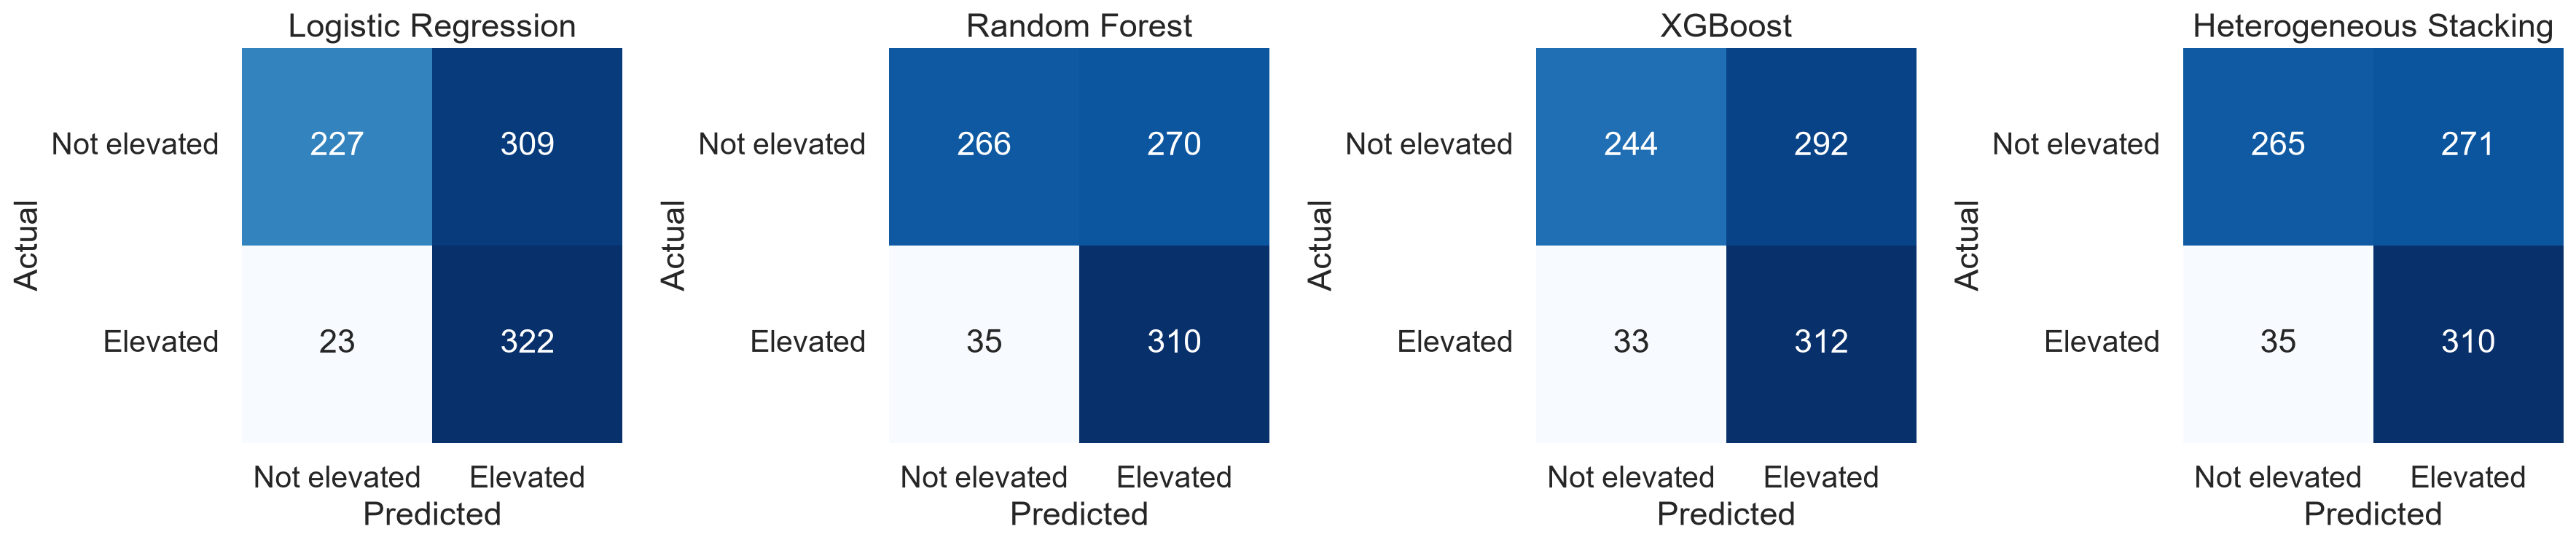

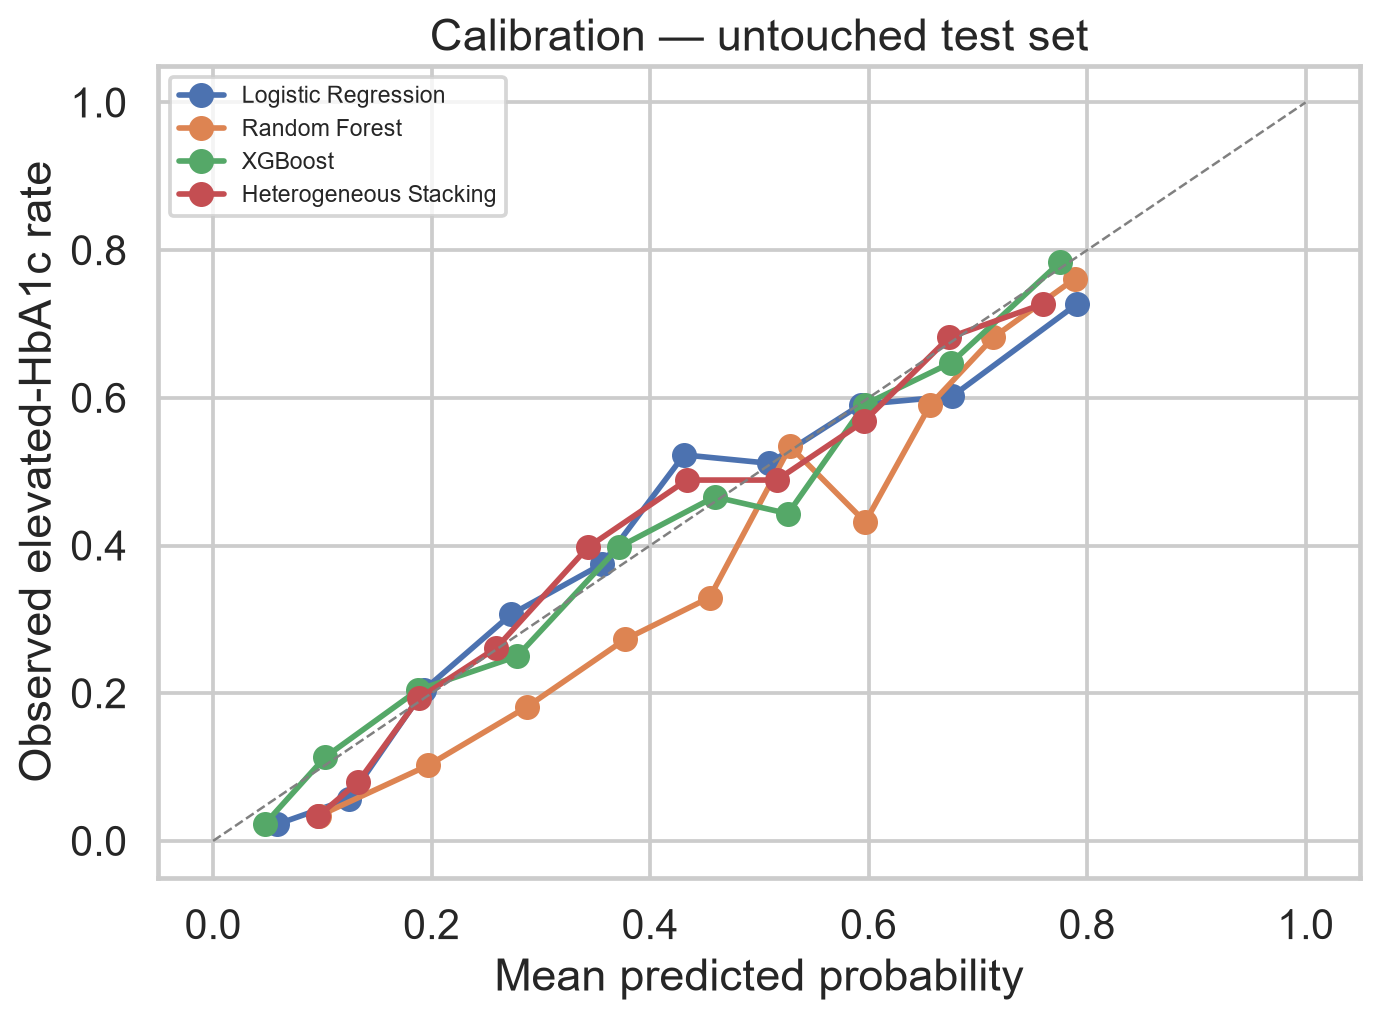

In [6]:
for figure in ['model_curves.png', 'confusion_matrices.png', 'calibration.png']:
    path = PROJECT_ROOT / 'reports' / 'figures' / figure
    if path.exists():
        display(Image(filename=str(path), width=1000))

## 4. Explainability and ethics

Model-agnostic SHAP explains the complete selected pipeline globally and for one fictional adult. Positive contributions increase the model output; negative contributions decrease it. They are associations, not causal effects. Fairness outputs compare sex, age, education, and income groups. Racial fairness cannot be claimed because race/ethnicity is not in the approved variable set.

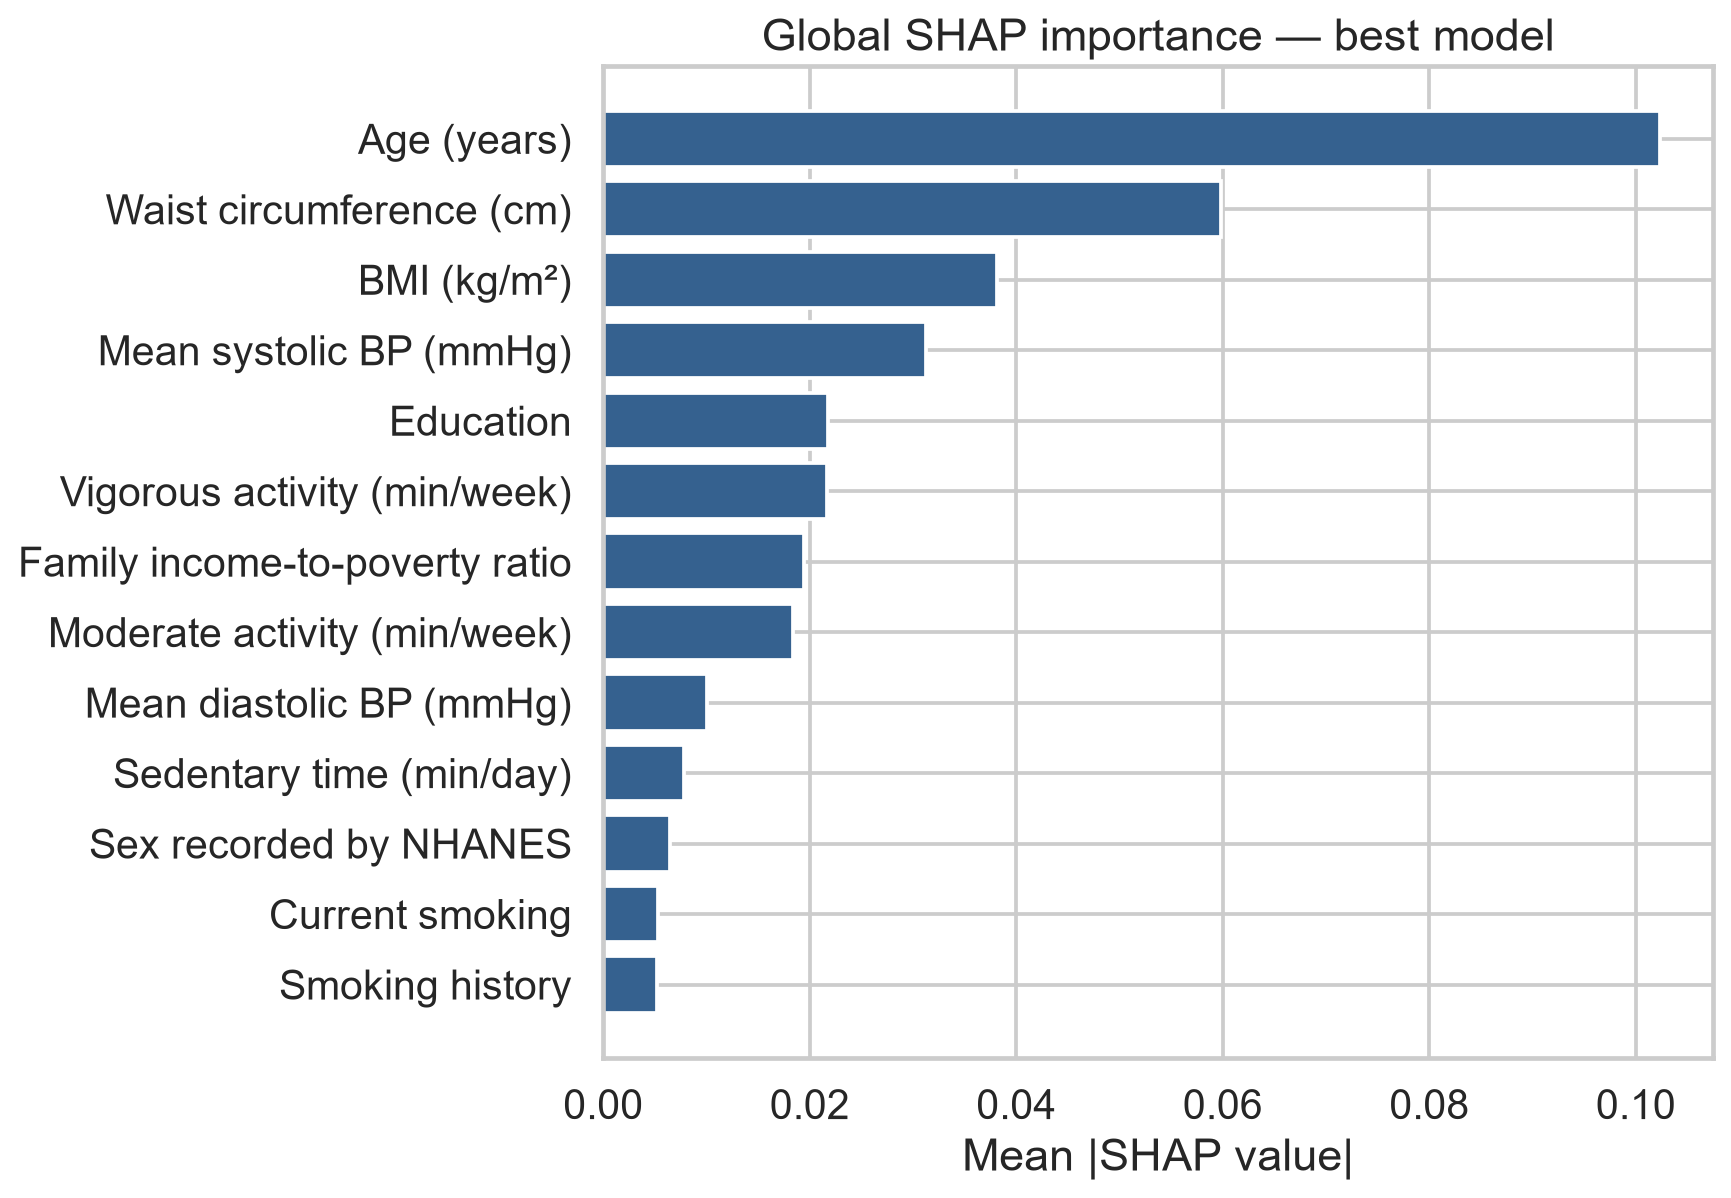

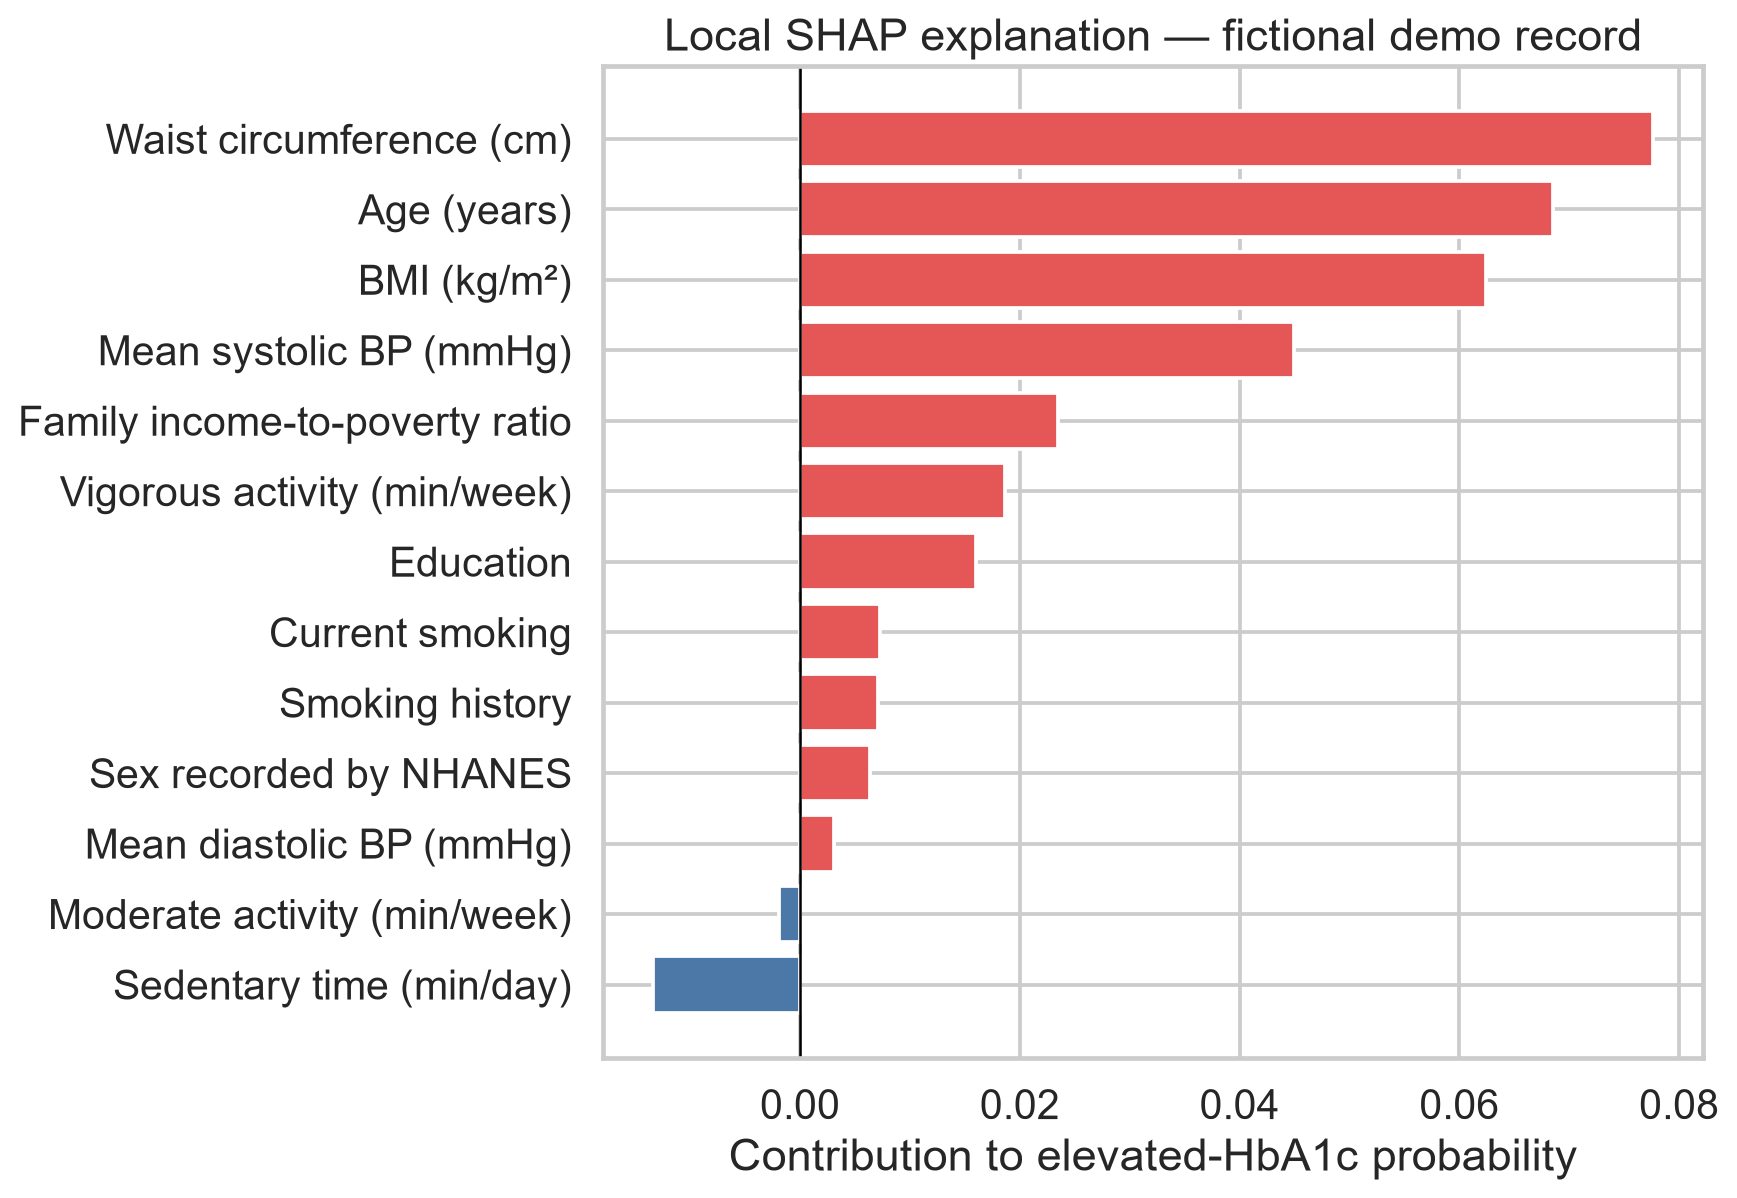

,attribute,group,n,positive_rate,roc_auc,precision,recall_tpr,false_negative_rate,false_positive_rate
0,sex,Female,508,0.378,0.774,0.523,0.896,0.104,0.497
1,sex,Male,373,0.410,0.792,0.550,0.902,0.098,0.514
2,age_group,19-39,232,0.125,0.754,0.333,0.379,0.621,0.108
3,age_group,40-59,249,0.373,0.774,0.491,0.903,0.097,0.558
4,age_group,60+,400,0.558,0.651,0.572,0.964,0.036,0.910
5,education,9-11th grade/no diploma,56,0.536,0.727,0.609,0.933,0.067,0.692
6,education,College graduate or above,307,0.270,0.762,0.410,0.795,0.205,0.424
7,education,High school/GED,193,0.461,0.765,0.562,0.921,0.079,0.615
8,education,Less than 9th grade,40,0.625,0.776,0.686,0.960,0.040,0.733
9,education,Some college/AA,267,0.442,0.736,0.573,0.932,0.068,0.550


In [7]:
for figure in ['shap_global_importance.png', 'shap_local_synthetic.png']:
    path = PROJECT_ROOT / 'reports' / 'figures' / figure
    if path.exists():
        display(Image(filename=str(path), width=900))
fairness_path = PROJECT_ROOT / 'reports' / 'fairness_subgroup_metrics.csv'
if fairness_path.exists():
    display(pd.read_csv(fairness_path).round(3))

## 5. Live demo and limitations

Launch `streamlit run app.py`. The app accepts a fictional adult record, applies the saved end-to-end pipeline, displays the validation-selected referral threshold, and computes a local SHAP explanation. False negatives may delay follow-up; false positives cause avoidable testing and anxiety. The model is cross-sectional, US-specific, partly self-reported, and not externally or prospectively validated.